# Imports

In [1]:
import glob
import hashlib
import os
import random
import sys
import time
import warnings
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
import torch
from joblib import Parallel, delayed
from scipy.fft import fft, fftfreq, ifft, rfft, rfftfreq
from scipy.interpolate import PchipInterpolator
from scipy.io import wavfile
from scipy.signal import find_peaks
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from tqdm.notebook import tqdm

# Hyperparameters

## Directories

In [2]:
DIR_PROJECT = Path("/home/mxadams/Dropbox/school_of_mines/CSCI575/project")
DIR_SRC = DIR_PROJECT / "CSCI575-project"
DIR_DATA = DIR_PROJECT / "Binary_Drone_Audio"
DIR_DRONE = DIR_DATA / "yes_drone"
DIR_UNKNOWN = DIR_DATA / "unknown"
DIR_TEST = DIR_DATA / "test"
DIR_CACHE = DIR_PROJECT / "feature_cache"

## Operating System

In [3]:
RANDOM_SEED = 42
NUM_WORKERS = -1
NUM_WORKERS_TORCH = 12

In [4]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## Data

In [5]:
TEST_FRAC = 0.2
SAMPLE_RATE = 16000
NUM_FREQUENCIES = 2**9
FREQ_SPACING_EXPONENT = 1.5
NUM_FEATURES = 88 + NUM_FREQUENCIES

In [6]:
arr = ((SAMPLE_RATE - 1) / 2) * (
    np.linspace(0.0, 1.0, NUM_FREQUENCIES) ** FREQ_SPACING_EXPONENT
) + 1
print(f"First Three Frequencies: {arr[:3]}")
print(f"Smallest Hidden Layer: {NUM_FEATURES//16}")

First Three Frequencies: [1.         1.69251868 2.95873862]
Smallest Hidden Layer: 37


## Neural Network

In [7]:
NN_PARAM_GRID = [
    {
        "learning_rate": np.logspace(-17, -13, num=5, base=2.0),
        "batch_size": np.logspace(6.0, 10.0, num=5, base=2.0).astype(int),
        "hidden_sizes": [
            (NUM_FEATURES // 2, NUM_FEATURES // 4, NUM_FEATURES // 8),
            (
                NUM_FEATURES // 2,
                NUM_FEATURES // 4,
                NUM_FEATURES // 8,
                NUM_FEATURES // 16,
            ),
        ],
        "max_epochs": [2**8],
        "train_converge_window": [2**5],
    },
]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# LEARNING_RATE = 2 ** (-16)
# BATCH_SIZE = 2**8
# MAX_NUM_EPOCHS = 2**8
# TRAIN_CONVERGE_WINDOW = 2**4
# TRAIN_CONVERGE_STD = 2 ** (-12)

## Random Forest

In [8]:
RF_PARAM_GRID = [
    {
        "n_estimators": np.logspace(5.0, 9.0, num=3, base=2.0).astype(int),
        "criterion": ["gini", "entropy", "log_loss"],
        "max_depth": [None],
        "min_samples_split": np.logspace(1.0, 3.0, num=3, base=2.0).astype(int),
        "min_samples_leaf": np.logspace(0.0, 2.0, num=3, base=2.0).astype(int),
        "max_features": ["sqrt", "log2"],
        "random_state": [RANDOM_SEED],
        "class_weight": ["balanced"],
    },
]

## Logistic Regression

In [9]:
LR_PARAM_GRID = [
    {
        "C": np.logspace(-6.0, 6.0, num=5, base=2.0),
        "l1_ratio": [0.0],
        "class_weight": ["balanced"],
        "random_state": [RANDOM_SEED],
        "solver": ["lbfgs", "newton-cg", "newton-cholesky", "sag"],
    },
    {
        "C": np.logspace(-6.0, 6.0, num=5, base=2.0),
        "l1_ratio": [0.0, 1.0],
        "class_weight": ["balanced"],
        "random_state": [RANDOM_SEED],
        "solver": ["liblinear"],
    },
    {
        "C": np.logspace(-6.0, 6.0, num=5, base=2.0),
        "l1_ratio": np.linspace(0.0, 1.0, 5),
        "class_weight": ["balanced"],
        "random_state": [RANDOM_SEED],
        "solver": ["saga"],
    },
]

## Support Vector Machine

In [10]:
SV_PARAM_GRID = [
    {
        "penalty": ["l2"],
        "loss": ["squared_hinge", "hinge"],
        "C": np.logspace(-6.0, 6.0, num=5, base=2.0),
        "class_weight": ["balanced"],
        "random_state": [RANDOM_SEED],
    },
    {
        "penalty": ["l1"],
        "loss": ["squared_hinge"],
        "C": np.logspace(-6.0, 6.0, num=5, base=2.0),
        "class_weight": ["balanced"],
        "random_state": [RANDOM_SEED],
    },
]

# Data

https://www.kaggle.com/datasets/amineipad/drone-sound-audio-detection

## Exploration

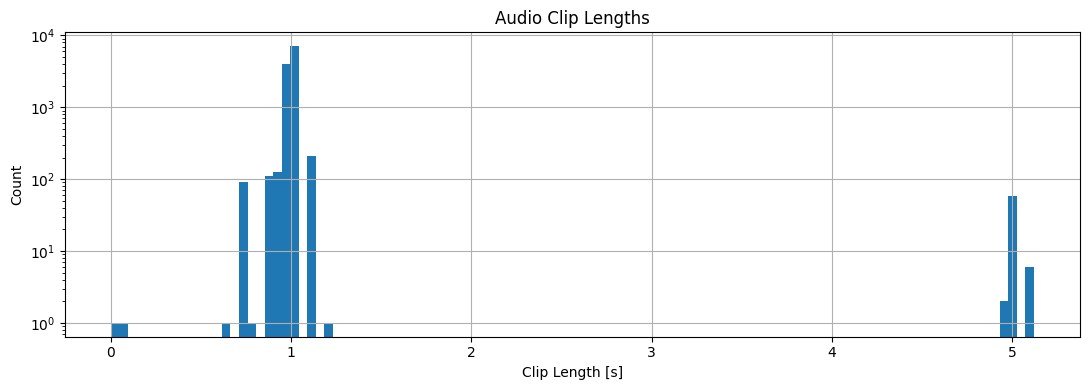

In [11]:
clip_lengths = np.array([])
for filename in os.listdir(DIR_DRONE):
    samplerate, data = wavfile.read(os.path.join(DIR_DRONE, filename))
    clip_lengths = np.append(clip_lengths, data.shape[0] / samplerate)
for filename in os.listdir(DIR_UNKNOWN):
    samplerate, data = wavfile.read(os.path.join(DIR_UNKNOWN, filename))
    clip_lengths = np.append(clip_lengths, data.shape[0] / samplerate)
plt.figure(figsize=(11, 4))
plt.hist(clip_lengths, bins=int(np.sqrt(len(clip_lengths))))
plt.title("Audio Clip Lengths")
plt.xlabel("Clip Length [s]")
plt.ylabel("Count")
plt.yscale("log")
plt.grid()
plt.tight_layout()

## Helper Functions

In [12]:
def extract_features(y, n_fft, sr=SAMPLE_RATE, min_samples=SAMPLE_RATE):
    if len(y) < min_samples:
        y = librosa.util.fix_length(y, size=min_samples)
    n_fft = 2 ** int(np.floor(np.log2(len(y))))
    hop_length = max(1, n_fft // 4)
    features = []
    S = np.abs(librosa.stft(y=y, n_fft=n_fft, hop_length=hop_length, center=True))
    mfcc = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=20, n_fft=n_fft, hop_length=hop_length
    )
    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))
    spec_centroid = librosa.feature.spectral_centroid(S=S, sr=sr)
    spec_bandwidth = librosa.feature.spectral_bandwidth(S=S, sr=sr)
    spec_rolloff = librosa.feature.spectral_rolloff(S=S, sr=sr)
    spec_contrast = librosa.feature.spectral_contrast(S=S, sr=sr, n_bands=6)
    for f in [spec_centroid, spec_bandwidth, spec_rolloff]:
        features.append(np.mean(f))
        features.append(np.std(f))
    features.extend(np.mean(spec_contrast, axis=1))
    features.extend(np.std(spec_contrast, axis=1))
    y_harm, y_perc = librosa.effects.hpss(y)
    features.append(np.sum(y_harm**2))
    features.append(np.sum(y_perc**2))
    zcr = librosa.feature.zero_crossing_rate(
        y, frame_length=n_fft, hop_length=hop_length
    )
    features.append(np.mean(zcr))
    features.append(np.std(zcr))
    chroma = librosa.feature.chroma_stft(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, tuning=0.0
    )
    features.extend(np.mean(chroma, axis=1))
    features.extend(np.std(chroma, axis=1))
    features = np.array(features, dtype=np.float32)
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    return features

In [13]:
def wav_to_data(filepath):
    samplerate, data = wavfile.read(filepath)
    if data.ndim > 1:
        data = data.mean(axis=1)
    if np.issubdtype(data.dtype, np.integer):
        max_val = np.iinfo(data.dtype).max
        data = data.astype(np.float32) / max_val
    else:
        data = data.astype(np.float32)
    data = data - np.mean(data)
    fft_val = rfft(data)
    fft_mag = np.abs(fft_val)
    fft_freq = rfftfreq(len(data), d=1.0 / samplerate)
    target_freq = ((samplerate - 1) / 2) * (
        np.linspace(0.0, 1.0, NUM_FREQUENCIES) ** FREQ_SPACING_EXPONENT
    ) + 1
    interp = PchipInterpolator(fft_freq, fft_mag, extrapolate=False)
    features = interp(target_freq)
    features = np.nan_to_num(features, nan=0.0)
    features = np.clip(features, 0.0, None)
    features = np.log1p(features)
    features = np.append(features, extract_features(data, len(fft_val)))
    return features.astype(np.float64)

In [14]:
def dataset_cache_path(dir_drone, dir_unknown):
    key = f"{dir_drone}_{dir_unknown}_{NUM_FEATURES}_{FREQ_SPACING_EXPONENT}"
    digest = hashlib.md5(key.encode()).hexdigest()[:10]
    return DIR_CACHE / f"features_{digest}.npz"

In [15]:
def list_wav_files(dir_drone, dir_unknown):
    files = []
    for label, folder in [(1, dir_drone), (0, dir_unknown)]:
        for path in sorted(folder.glob("*.wav")):
            files.append((str(path), label))
    return files

In [16]:
def process_one_file(filepath, label):
    try:
        features = wav_to_data(filepath)
        return features.astype(np.float32), label, None
    except Exception as e:
        return None, label, f"Skipping {filepath}: {e}"

In [17]:
def load_dataset_fast(
    dir_drone,
    dir_unknown,
    n_jobs=NUM_WORKERS,
    use_cache=True,
):
    cache_path = dataset_cache_path(dir_drone, dir_unknown)
    if use_cache and cache_path.exists():
        cached = np.load(cache_path)
        X = cached["X"]
        y = cached["y"]
        return X, y
    files = list_wav_files(dir_drone, dir_unknown)
    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(process_one_file)(filepath, label)
        for filepath, label in tqdm(files, leave=True)
    )
    X = []
    y = []
    for features, label, error in results:
        if error is not None:
            print(error)
            continue
        X.append(features)
        y.append(label)
    X = np.stack(X).astype(np.float32)
    y = np.array(y, dtype=np.int64)
    if use_cache:
        np.savez_compressed(cache_path, X=X, y=y)
        print(f"Saved cached features to {cache_path}")
    return X, y

In [18]:
def seed_everything(seed: int = RANDOM_SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)

## Data Setup

In [19]:
seed_everything(RANDOM_SEED)

In [20]:
DIR_CACHE.mkdir(exist_ok=True)
data_load_time = time.perf_counter()
X_np, y_np = load_dataset_fast(dir_drone=DIR_DRONE, dir_unknown=DIR_UNKNOWN)
X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=TEST_FRAC, random_state=RANDOM_SEED, stratify=y_np
)
data_scaler = StandardScaler()
X_train = data_scaler.fit_transform(X_train)
X_test = data_scaler.transform(X_test)
data_load_time = time.perf_counter() - data_load_time
print(f"Data Loaded in {data_load_time:.3f} seconds")

Data Loaded in 0.123 seconds


# Model Testing

## Neural Network

### Helper Functions

In [21]:
def evaluate_nn(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    all_preds = []
    all_labels = []
    all_drone_probs = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            test_loss += loss.item() * X_batch.size(0)
            probs = torch.softmax(logits, dim=1)
            drone_probs = probs[:, 1]
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())
            all_drone_probs.append(drone_probs.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_drone_probs = torch.cat(all_drone_probs).numpy()
    avg_loss = test_loss / len(test_loader.dataset)
    drone_true = (all_labels == 1).astype(int)
    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "balanced_accuracy": balanced_accuracy_score(all_labels, all_preds),
        "drone_precision": precision_score(all_labels, all_preds, zero_division=0),
        "drone_recall": recall_score(all_labels, all_preds, zero_division=0),
        "drone_f1": f1_score(all_labels, all_preds, zero_division=0),
        "drone_pr_auc": average_precision_score(drone_true, all_drone_probs),
        "confusion_matrix": confusion_matrix(all_labels, all_preds, labels=[0, 1]),
    }
    return metrics

### Model Definition

In [22]:
class NeuralNet(torch.nn.Module):
    def __init__(self, input_dim, hidden_sizes):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_sizes:
            layers.append(torch.nn.Linear(prev_dim, hidden_dim))
            layers.append(torch.nn.ReLU())
            prev_dim = hidden_dim
        layers.append(torch.nn.Linear(prev_dim, 2))
        self.network = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

### Model Setup

In [23]:
# train_dataset = TensorDataset(
#     torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long)
# )
# test_dataset = TensorDataset(
#     torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)
# )

In [24]:
# generator = torch.Generator()
# generator.manual_seed(RANDOM_SEED)

In [25]:
# train_loader = DataLoader(
#     train_dataset,
#     batch_size=BATCH_SIZE,
#     num_workers=12,
#     shuffle=False,
#     generator=generator,
# )
# test_loader = DataLoader(
#     test_dataset,
#     batch_size=BATCH_SIZE,
#     num_workers=12,
#     shuffle=False,
#     generator=generator,
# )

In [26]:
# seed_everything(RANDOM_SEED)

In [27]:
# model = NeuralNet().to(DEVICE)
# train_labels = torch.tensor(
#     [train_dataset[i][1].item() for i in range(len(train_dataset))]
# )
# class_counts = torch.bincount(train_labels, minlength=2)
# loss_class_weights = len(train_labels) / (len(class_counts) * class_counts.float())
# criterion = torch.nn.CrossEntropyLoss(weight=loss_class_weights.to(DEVICE))
# optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

### Model Training

In [28]:
# nn_train_time = time.perf_counter()
# plot_data = {
#     "epoch": np.array([0.0]),
#     "train_loss": np.array([1.0]),
#     "test_loss": np.array([1.0]),
#     "accuracy": np.array([0.0]),
#     "balanced_accuracy": np.array([0.0]),
#     "precision": np.array([0.0]),
#     "recall": np.array([0.0]),
#     "f1-score": np.array([0.0]),
#     "pr-auc": np.array([0.0]),
# }
# for epoch in range(MAX_NUM_EPOCHS):
#     model.train()
#     total_loss = 0.0
#     for X_batch, y_batch in train_loader:
#         X_batch = X_batch.to(DEVICE)
#         y_batch = y_batch.to(DEVICE)
#         logits = model(X_batch)
#         loss = criterion(logits, y_batch)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item() * X_batch.size(0)
#     avg_train_loss = total_loss / len(train_loader.dataset)
#     metrics = evaluate_nn(
#         model=model, test_loader=test_loader, criterion=criterion, device=DEVICE
#     )
#     plot_data["epoch"] = np.append(plot_data["epoch"], epoch + 1)
#     plot_data["train_loss"] = np.append(plot_data["train_loss"], avg_train_loss)
#     plot_data["test_loss"] = np.append(plot_data["test_loss"], metrics["loss"])
#     plot_data["accuracy"] = np.append(plot_data["accuracy"], metrics["accuracy"])
#     plot_data["balanced_accuracy"] = np.append(
#         plot_data["balanced_accuracy"], metrics["balanced_accuracy"]
#     )
#     plot_data["precision"] = np.append(
#         plot_data["precision"], metrics["drone_precision"]
#     )
#     plot_data["recall"] = np.append(plot_data["recall"], metrics["drone_recall"])
#     plot_data["f1-score"] = np.append(plot_data["f1-score"], metrics["drone_f1"])
#     plot_data["pr-auc"] = np.append(plot_data["pr-auc"], metrics["drone_pr_auc"])
#     print(
#         f"Epoch {str(int(plot_data["epoch"][-1])).rjust(len(str(MAX_NUM_EPOCHS)))}/{MAX_NUM_EPOCHS}  |  "
#         f"Train loss: {plot_data["train_loss"][-1]:.4f}  |  "
#         f"Test loss: {plot_data["test_loss"][-1]:.4f}  |  "
#         f"Acc: {plot_data["accuracy"][-1]:.4f}  |  "
#         f"Bal acc: {plot_data["balanced_accuracy"][-1]:.4f}  |  "
#         f"Prec: {plot_data["precision"][-1]:.4f}  |  "
#         f"Rec: {plot_data["recall"][-1]:.4f}  |  "
#         f"F1: {plot_data["f1-score"][-1]:.4f}  |  "
#         f"PR-AUC: {plot_data["pr-auc"][-1]:.4f}"
#     )
#     if len(plot_data["f1-score"]) > 2 * TRAIN_CONVERGE_WINDOW:
#         train_converge_std = plot_data["f1-score"][
#             len(plot_data["f1-score"]) - TRAIN_CONVERGE_WINDOW :
#         ].std()
#         train_converge_mean = plot_data["f1-score"][
#             len(plot_data["f1-score"]) - TRAIN_CONVERGE_WINDOW :
#         ].mean()
#         if train_converge_std < TRAIN_CONVERGE_STD:
#             print(
#                 f"F1 Score Converged to {train_converge_mean:.5f} +/- {train_converge_std:.5f}"
#             )
#             break
# nn_train_time = time.perf_counter() - nn_train_time
# print(f"Trained Neural Network in {nn_train_time:.3f} seconds")

In [29]:
def train_nn_once(
    X_train_fold, y_train_fold, X_test_fold, y_test_fold, params, device=DEVICE
):
    seed_everything(RANDOM_SEED)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_test_scaled = scaler.transform(X_test_fold)
    train_dataset = TensorDataset(
        torch.tensor(X_train_scaled, dtype=torch.float32),
        torch.tensor(y_train_fold, dtype=torch.long),
    )
    test_dataset = TensorDataset(
        torch.tensor(X_test_scaled, dtype=torch.float32),
        torch.tensor(y_test_fold, dtype=torch.long),
    )
    generator = torch.Generator()
    generator.manual_seed(RANDOM_SEED)
    train_loader = DataLoader(
        train_dataset,
        batch_size=int(params["batch_size"]),
        shuffle=True,
        num_workers=NUM_WORKERS_TORCH,
        generator=generator,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=int(params["batch_size"]),
        shuffle=False,
        num_workers=NUM_WORKERS_TORCH,
    )
    model = NeuralNet(
        input_dim=X_train_scaled.shape[1], hidden_sizes=params["hidden_sizes"]
    ).to(device)
    train_labels = torch.tensor(y_train_fold, dtype=torch.long)
    class_counts = torch.bincount(train_labels, minlength=2)
    loss_class_weights = len(train_labels) / (len(class_counts) * class_counts.float())
    criterion = torch.nn.CrossEntropyLoss(weight=loss_class_weights.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=params["learning_rate"])
    best_f1 = -np.inf
    best_metrics = None
    patience = params["train_converge_window"]
    epochs_without_improvement = 0
    for epoch in range(params["max_epochs"]):
        model.train()
        total_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
        metrics = evaluate_nn(
            model=model, test_loader=test_loader, criterion=criterion, device=device
        )
        test_f1 = metrics["drone_f1"]
        if test_f1 > best_f1:
            best_f1 = test_f1
            best_metrics = metrics
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            break
    return best_f1, best_metrics

In [ ]:
nn_grid_time = time.perf_counter()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
nn_grid_results = []
for params in ParameterGrid(NN_PARAM_GRID):
    fold_scores = []
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train)):
        X_train_fold = X_train[train_idx]
        y_train_fold = y_train[train_idx]
        X_test_fold = X_train[test_idx]
        y_test_fold = y_train[test_idx]
        fold_f1, fold_metrics = train_nn_once(
            X_train_fold=X_train_fold,
            y_train_fold=y_train_fold,
            X_test_fold=X_test_fold,
            y_test_fold=y_test_fold,
            params=params,
            device=DEVICE,
        )
        fold_scores.append(fold_f1)
    result = {**params, "mean_f1": np.mean(fold_scores), "std_f1": np.std(fold_scores)}
    nn_grid_results.append(result)
    print(
        f"Params: {params} | "
        f"Mean F1: {result['mean_f1']:.4f} | "
        f"Std F1: {result['std_f1']:.4f}"
    )
nn_grid_time = time.perf_counter() - nn_grid_time
nn_grid_df = pd.DataFrame(nn_grid_results)
nn_grid_df = nn_grid_df.sort_values("mean_f1", ascending=False)
best_nn_params = nn_grid_df.iloc[0].to_dict()
print(f"NN grid search completed in {nn_grid_time:.3f} seconds")
print("Best NN params:")
print(best_nn_params)
nn_grid_df

In [ ]:
def train_final_nn(X_train, y_train, X_test, y_test, params, device=DEVICE):
    seed_everything(RANDOM_SEED)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    train_dataset = TensorDataset(
        torch.tensor(X_train_scaled, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long),
    )
    test_dataset = TensorDataset(
        torch.tensor(X_test_scaled, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long),
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=int(params["batch_size"]),
        shuffle=True,
        num_workers=NUM_WORKERS_TORCH,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=int(params["batch_size"]),
        shuffle=False,
        num_workers=NUM_WORKERS_TORCH,
    )
    model = NeuralNet(
        input_dim=X_train_scaled.shape[1], hidden_sizes=params["hidden_sizes"]
    ).to(device)
    train_labels = torch.tensor(y_train, dtype=torch.long)
    class_counts = torch.bincount(train_labels, minlength=2)
    loss_class_weights = len(train_labels) / (len(class_counts) * class_counts.float())
    criterion = torch.nn.CrossEntropyLoss(weight=loss_class_weights.to(device))
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=float(params["learning_rate"]),
        weight_decay=float(params["weight_decay"]),
    )
    for epoch in range(int(params["max_epochs"])):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    test_metrics = evaluate_nn(
        model=model, test_loader=test_loader, criterion=criterion, device=device
    )
    return model, scaler, test_metrics

In [ ]:
final_nn_model, final_nn_scaler, nn_metrics = train_final_nn(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    params=best_nn_params,
    device=DEVICE,
)

print(
    f"Acc: {nn_metrics['accuracy']:.4f}  |  "
    f"Bal acc: {nn_metrics['balanced_accuracy']:.4f}  |  "
    f"Prec: {nn_metrics['drone_precision']:.4f}  |  "
    f"Rec: {nn_metrics['drone_recall']:.4f}  |  "
    f"F1: {nn_metrics['drone_f1']:.4f}  |  "
    f"PR-AUC: {nn_metrics['drone_pr_auc']:.4f}"
)

### Plot Model Metrics

In [ ]:
plt.figure(figsize=(16, 9))
plt.plot(plot_data["epoch"], plot_data["train_loss"], ".-", label="Train Loss")
plt.plot(plot_data["epoch"], plot_data["test_loss"], ".-", label="Test Loss")
plt.plot(plot_data["epoch"], plot_data["accuracy"], ".-", label="Test Accuracy")
plt.plot(
    plot_data["epoch"],
    plot_data["balanced_accuracy"],
    ".-",
    label="Balanced Test Accuracy",
)
plt.plot(plot_data["epoch"], plot_data["precision"], ".-", label="Test Precision")
plt.plot(plot_data["epoch"], plot_data["recall"], ".-", label="Test Recall")
plt.plot(plot_data["epoch"], plot_data["f1-score"], ".-", label="Test F1 Score")
# plt.plot(plot_data["epoch"], plot_data["pr-auc"], ".-", label="Average Test Precision")
plt.xlim([0, len(plot_data["epoch"])])
plt.ylim([0, 1])
plt.xticks(
    np.append(np.arange(0, len(plot_data["epoch"]) - 4, 5), plot_data["epoch"][-1])
)
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.legend()
plt.grid()
plt.title("Neural Network Training Metrics")
plt.xlabel("Epoch")
plt.tight_layout()
plt.savefig("nn_training.png", format="png")
plt.show()
plt.close()

In [ ]:
# nn_metrics = evaluate_nn(
#     model=model, test_loader=test_loader, criterion=criterion, device=DEVICE
# )
cm = nn_metrics["confusion_matrix"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["unknown", "drone"])
disp.plot()
plt.title("Neural Network Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.savefig("nn_cm.png", format="png")
plt.show()
plt.close()

## Random Forest

### Model Fitting

In [ ]:
seed_everything(RANDOM_SEED)

In [ ]:
rf_train_time = time.perf_counter()
rf_model = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=RF_PARAM_GRID,
    scoring="f1",
    cv=5,
    n_jobs=NUM_WORKERS,
)
rf_n_candidates = len(list(ParameterGrid(RF_PARAM_GRID)))
rf_n_fits = rf_n_candidates * rf_model.cv
rf_model.fit(X_train, y_train)
rf_train_time = time.perf_counter() - rf_train_time
print(f"Trained Random Forest in {rf_train_time:.3f} seconds")

### Model Evaluation

In [ ]:
rf_preds = rf_model.predict(X_test)
rf_metrics = {
    "accuracy": accuracy_score(y_test, rf_preds),
    "balanced_accuracy": balanced_accuracy_score(y_test, rf_preds),
    "precision": precision_score(y_test, rf_preds, zero_division=0),
    "recall": recall_score(y_test, rf_preds, zero_division=0),
    "f1-score": f1_score(y_test, rf_preds, zero_division=0),
    "confusion_matrix": confusion_matrix(y_test, rf_preds, labels=[0, 1]),
}
print(
    f"Acc: {rf_metrics["accuracy"]:.4f}  |  "
    f"Bal acc: {rf_metrics["balanced_accuracy"]:.4f}  |  "
    f"Prec: {rf_metrics["precision"]:.4f}  |  "
    f"Rec: {rf_metrics["recall"]:.4f}  |  "
    f"F1: {rf_metrics["f1-score"]:.4f}"
)

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds, labels=[0, 1], display_labels=["unknown", "drone"]
)
plt.title("Random Forest Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.savefig("rf_cm.png", format="png")
plt.show()
plt.close()

## Logistic Regression

### Model Fitting

In [ ]:
seed_everything(RANDOM_SEED)

In [ ]:
lr_train_time = time.perf_counter()
lr_model = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=LR_PARAM_GRID,
    scoring="f1",
    cv=5,
    n_jobs=NUM_WORKERS,
)
lr_n_candidates = len(list(ParameterGrid(LR_PARAM_GRID)))
lr_n_fits = lr_n_candidates * lr_model.cv
lr_model.fit(X_train, y_train)
lr_train_time = time.perf_counter() - lr_train_time
print(f"Trained Logistic Regression in {lr_train_time:.3f} seconds")

### Model Evaluation

In [ ]:
lr_preds = lr_model.predict(X_test)
lr_metrics = {
    "accuracy": accuracy_score(y_test, lr_preds),
    "balanced_accuracy": balanced_accuracy_score(y_test, lr_preds),
    "precision": precision_score(y_test, lr_preds, zero_division=0),
    "recall": recall_score(y_test, lr_preds, zero_division=0),
    "f1-score": f1_score(y_test, lr_preds, zero_division=0),
    "confusion_matrix": confusion_matrix(y_test, lr_preds, labels=[0, 1]),
}
print(
    f"Acc: {lr_metrics["accuracy"]:.4f}  |  "
    f"Bal acc: {lr_metrics["balanced_accuracy"]:.4f}  |  "
    f"Prec: {lr_metrics["precision"]:.4f}  |  "
    f"Rec: {lr_metrics["recall"]:.4f}  |  "
    f"F1: {lr_metrics["f1-score"]:.4f}"
)

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_preds, labels=[0, 1], display_labels=["unknown", "drone"]
)
plt.title("Logistic Regression Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.savefig("lr_cm.png", format="png")
plt.show()
plt.close()

## Support Vector Machine

### Model Fitting

In [ ]:
seed_everything(RANDOM_SEED)

In [ ]:
sv_train_time = time.perf_counter()
sv_model = GridSearchCV(
    estimator=LinearSVC(),
    param_grid=RF_PARAM_GRID,
    scoring="f1",
    cv=5,
    n_jobs=NUM_WORKERS,
)
sv_n_candidates = len(list(ParameterGrid(SV_PARAM_GRID)))
sv_n_fits = sv_n_candidates * sv_model.cv
sv_model.fit(X_train, y_train)
sv_train_time = time.perf_counter() - sv_train_time
print(f"Trained Support Vector Machine in {sv_train_time:.3f} seconds")

### Model Evaluation

In [ ]:
sv_preds = sv_model.predict(X_test)
sv_metrics = {
    "accuracy": accuracy_score(y_test, sv_preds),
    "balanced_accuracy": balanced_accuracy_score(y_test, sv_preds),
    "precision": precision_score(y_test, sv_preds, zero_division=0),
    "recall": recall_score(y_test, sv_preds, zero_division=0),
    "f1-score": f1_score(y_test, sv_preds, zero_division=0),
    "confusion_matrix": confusion_matrix(y_test, sv_preds, labels=[0, 1]),
}
print(
    f"Acc: {sv_metrics["accuracy"]:.4f}  |  "
    f"Bal acc: {sv_metrics["balanced_accuracy"]:.4f}  |  "
    f"Prec: {sv_metrics["precision"]:.4f}  |  "
    f"Rec: {sv_metrics["recall"]:.4f}  |  "
    f"F1: {sv_metrics["f1-score"]:.4f}"
)

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test, sv_preds, labels=[0, 1], display_labels=["unknown", "drone"]
)
plt.title("Support Vector Classifier Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.savefig("sv_cm.png", format="png")
plt.show()
plt.close()

# Model Comparison

In [ ]:
training_times = [nn_train_time, rf_train_time, lr_train_time, sv_train_time]
f1_scores = [
    nn_metrics["drone_f1"],
    rf_metrics["f1-score"],
    lr_metrics["f1-score"],
    sv_metrics["f1-score"],
]
plt.figure(figsize=(16, 9))
plt.plot(training_times[0], f1_scores[0], "o", ms=9, label="Neural Network")
plt.plot(training_times[1], f1_scores[1], "s", ms=9, label="Random Forest")
plt.plot(training_times[2], f1_scores[2], "^", ms=9, label="Logistic Regression")
plt.plot(training_times[3], f1_scores[3], "*", ms=10, label="Support Vector Classifier")
plt.title("F1 Scores vs. Training Times")
plt.xlabel("Training Time [s]")
plt.ylabel("F1 Score")
plt.xscale("log")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("train_times.png", format="png")
plt.show()
plt.close()

# Live Demo

In [ ]:
def load_ext_dataset(dir_test):
    X_ext = []
    filenames = []
    for filename in os.listdir(dir_test):
        if not filename.lower().endswith(".wav"):
            continue
        filepath = dir_test / filename
        try:
            features = wav_to_data(filepath)
            X_ext.append(features)
            filenames.append(filename)
        except Exception as e:
            print(f"Skipping {filepath}: {e}")
    X_ext = np.stack(X_ext)
    return X_ext, filenames

In [ ]:
X_ext, filenames_ext = load_ext_dataset(DIR_TEST)

In [ ]:
rf_preds = rf_model.predict(X_ext)
rf_metrics = {
    "accuracy": accuracy_score(y_test, rf_preds),
    "balanced_accuracy": balanced_accuracy_score(y_test, rf_preds),
    "precision": precision_score(y_test, rf_preds, zero_division=0),
    "recall": recall_score(y_test, rf_preds, zero_division=0),
    "f1-score": f1_score(y_test, rf_preds, zero_division=0),
    "confusion_matrix": confusion_matrix(y_test, rf_preds, labels=[0, 1]),
}
print(
    f"Acc: {rf_metrics["accuracy"]:.4f}  |  "
    f"Bal acc: {rf_metrics["balanced_accuracy"]:.4f}  |  "
    f"Prec: {rf_metrics["precision"]:.4f}  |  "
    f"Rec: {rf_metrics["recall"]:.4f}  |  "
    f"F1: {rf_metrics["f1-score"]:.4f}"
)

In [ ]:
lr_preds = lr_model.predict(X_ext)
lr_metrics = {
    "accuracy": accuracy_score(y_test, lr_preds),
    "balanced_accuracy": balanced_accuracy_score(y_test, lr_preds),
    "precision": precision_score(y_test, lr_preds, zero_division=0),
    "recall": recall_score(y_test, lr_preds, zero_division=0),
    "f1-score": f1_score(y_test, lr_preds, zero_division=0),
    "confusion_matrix": confusion_matrix(y_test, lr_preds, labels=[0, 1]),
}
print(
    f"Acc: {lr_metrics["accuracy"]:.4f}  |  "
    f"Bal acc: {lr_metrics["balanced_accuracy"]:.4f}  |  "
    f"Prec: {lr_metrics["precision"]:.4f}  |  "
    f"Rec: {lr_metrics["recall"]:.4f}  |  "
    f"F1: {lr_metrics["f1-score"]:.4f}"
)

In [ ]:
sv_preds = sv_model.predict(X_ext)
sv_metrics = {
    "accuracy": accuracy_score(y_test, sv_preds),
    "balanced_accuracy": balanced_accuracy_score(y_test, sv_preds),
    "precision": precision_score(y_test, sv_preds, zero_division=0),
    "recall": recall_score(y_test, sv_preds, zero_division=0),
    "f1-score": f1_score(y_test, sv_preds, zero_division=0),
    "confusion_matrix": confusion_matrix(y_test, sv_preds, labels=[0, 1]),
}
print(
    f"Acc: {sv_metrics["accuracy"]:.4f}  |  "
    f"Bal acc: {sv_metrics["balanced_accuracy"]:.4f}  |  "
    f"Prec: {sv_metrics["precision"]:.4f}  |  "
    f"Rec: {sv_metrics["recall"]:.4f}  |  "
    f"F1: {sv_metrics["f1-score"]:.4f}"
)